# Day 6-7: Project: Multi-class Text Classification 🚀

Welcome to the comprehensive multi-class text classification project! This notebook combines all the concepts learned in the previous days to build a production-ready text classification system.

## Learning Objectives
- Build a complete multi-class text classification pipeline
- Implement ensemble methods and advanced techniques
- Create a production-ready classification system
- Deploy and test the model with real-world data
- Build a complete NLP application

## What You'll Build
1. **Advanced Text Preprocessing**: Multi-language support and domain-specific cleaning
2. **Feature Engineering**: TF-IDF, word embeddings, and statistical features
3. **Ensemble Methods**: Voting, stacking, and bagging classifiers
4. **Model Optimization**: Advanced hyperparameter tuning and feature selection
5. **Production Pipeline**: Model serving, API development, and monitoring
6. **Real-world Application**: News categorization, document classification, or sentiment analysis

## 1. Advanced Setup and Imports

In [2]:
# Advanced imports for production-ready NLP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Advanced ML imports
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, learning_curve, validation_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, BaggingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, recall_score, precision_score
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.cluster import KMeans

# Advanced text processing
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer, LancasterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize, RegexpTokenizer
from nltk.util import ngrams
from nltk.sentiment import SentimentIntensityAnalyzer

# Word embeddings and advanced NLP
try:
    import gensim
    from gensim.models import Word2Vec, FastText
    from gensim.parsing.preprocessing import preprocess_string, strip_tags, strip_punctuation
    GENSIM_AVAILABLE = True
except ImportError:
    GENSIM_AVAILABLE = False
    print("⚠️ Gensim not available. Word2Vec features will be skipped.")

# Download required NLTK data
required_nltk_data = ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'vader_lexicon']
for item in required_nltk_data:
    try:
        nltk.data.find(f'tokenizers/{item}' if 'punkt' in item else f'corpora/{item}')
    except LookupError:
        nltk.download(item)

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)

print("✅ All advanced imports successful!")
print(f"✅ Gensim available: {GENSIM_AVAILABLE}")

⚠️ Gensim not available. Word2Vec features will be skipped.
✅ All advanced imports successful!
✅ Gensim available: False


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\piers\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\piers\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\piers\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 2. Advanced Data Preparation

Let's create a comprehensive multi-class dataset with real-world complexity.

Dataset shape: (50, 4)
Categories: ['technology' 'healthcare' 'finance' 'education' 'environment']

Category distribution:
category
technology     10
healthcare     10
finance        10
education      10
environment    10
Name: count, dtype: int64

Dataset Statistics:
Average text length: 102.0 characters
Average word count: 11.9 words
Text length range: 76 - 138 characters
Word count range: 9 - 16 words


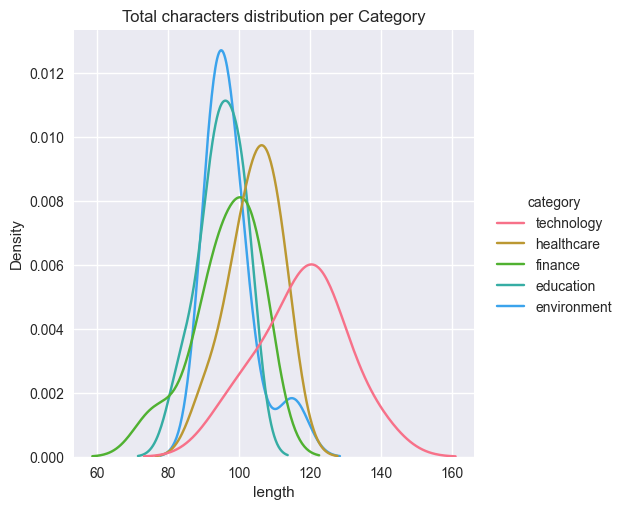

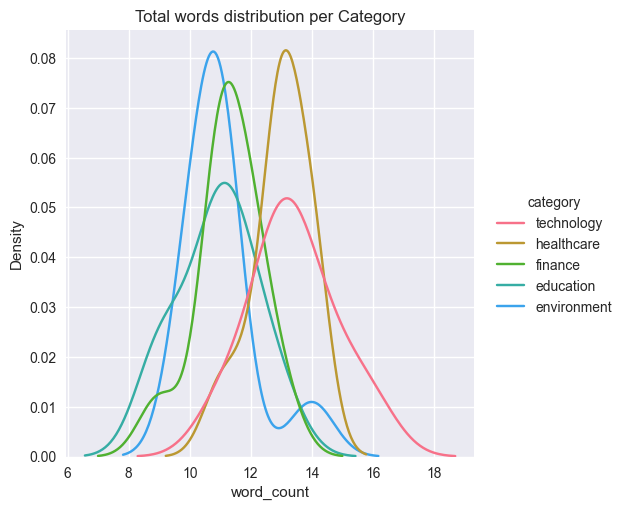

In [3]:
# Create a comprehensive multi-class dataset
def create_mock_text_dataset():
    """Create a complex multi-class dataset with multiple domains"""
    
    # Technology & AI texts
    tech_texts = [
        "Artificial intelligence and machine learning algorithms are revolutionizing data analysis and decision-making processes across industries.",
        "The Internet of Things (IoT) connects billions of devices, enabling smart cities and automated infrastructure management.",
        "Blockchain technology ensures secure, transparent, and immutable transactions in cryptocurrency and supply chain applications.",
        "Cloud computing provides scalable, on-demand infrastructure that reduces costs and increases operational efficiency.",
        "Cybersecurity measures protect against sophisticated cyber threats, including ransomware, phishing, and zero-day exploits.",
        "Virtual and augmented reality technologies are transforming gaming, education, and professional training experiences.",
        "Quantum computing promises exponential speed improvements for complex computational problems in cryptography and optimization.",
        "5G networks enable ultra-fast, low-latency connectivity for autonomous vehicles and smart manufacturing.",
        "Robotics and automation systems are reshaping manufacturing, healthcare, and service industries.",
        "Data science combines statistical analysis, programming, and domain expertise to extract actionable insights."
    ]
    
    # Healthcare & Medicine texts
    health_texts = [
        "Precision medicine tailors treatment plans based on individual genetic profiles and molecular characteristics.",
        "Telemedicine platforms provide remote healthcare access, improving patient outcomes and reducing healthcare costs.",
        "Immunotherapy treatments harness the body's immune system to fight cancer and autoimmune diseases.",
        "Gene editing technologies like CRISPR offer potential cures for genetic disorders and inherited conditions.",
        "Digital health tools monitor vital signs, track medication adherence, and provide personalized health insights.",
        "Mental health awareness and treatment options have expanded significantly in recent years.",
        "Preventive medicine focuses on early detection and lifestyle modifications to prevent chronic diseases.",
        "Regenerative medicine uses stem cells and tissue engineering to repair damaged organs and tissues.",
        "Global health initiatives address infectious diseases, maternal health, and access to essential medicines.",
        "Medical imaging technologies provide non-invasive diagnostic capabilities for various health conditions."
    ]
    
    # Finance & Economics texts
    finance_texts = [
        "Cryptocurrency markets experience high volatility due to regulatory uncertainty and market speculation.",
        "Central banks implement monetary policies to control inflation and maintain economic stability.",
        "Sustainable investing integrates environmental, social, and governance factors into investment decisions.",
        "Fintech innovations democratize access to financial services through mobile banking and digital payments.",
        "Risk management strategies protect portfolios against market volatility and economic downturns.",
        "International trade agreements facilitate global commerce and economic cooperation between nations.",
        "Real estate markets reflect economic conditions, interest rates, and demographic trends.",
        "Retirement planning requires understanding of investment vehicles, tax implications, and longevity risk.",
        "Insurance products provide financial protection against various risks and unexpected events.",
        "Economic indicators measure economic performance and guide policy decisions."
    ]
    
    # Education & Learning texts
    education_texts = [
        "Online learning platforms provide flexible, accessible education opportunities for diverse learners.",
        "Personalized learning adapts educational content to individual learning styles and pace.",
        "STEM education prepares students for careers in science, technology, engineering, and mathematics.",
        "Lifelong learning enables continuous skill development and career advancement in changing job markets.",
        "Blended learning combines traditional classroom instruction with digital tools and resources.",
        "Educational technology enhances engagement and improves learning outcomes through interactive content.",
        "Project-based learning develops critical thinking, collaboration, and problem-solving skills.",
        "Global education initiatives promote cross-cultural understanding and international cooperation.",
        "Adult education programs support career transitions and personal development goals.",
        "Special education services provide tailored support for students with diverse learning needs."
    ]
    
    # Environment & Sustainability texts
    environment_texts = [
        "Climate change mitigation requires reducing greenhouse gas emissions and transitioning to renewable energy sources.",
        "Sustainable agriculture practices minimize environmental impact while ensuring food security.",
        "Biodiversity conservation protects ecosystems and maintains ecological balance for future generations.",
        "Circular economy principles reduce waste through reuse, recycling, and resource optimization.",
        "Renewable energy technologies provide clean alternatives to fossil fuel-based power generation.",
        "Environmental regulations establish standards for pollution control and natural resource protection.",
        "Green building practices incorporate energy efficiency and sustainable materials in construction.",
        "Water conservation strategies address scarcity and ensure sustainable water resource management.",
        "Waste reduction initiatives minimize landfill contributions and promote recycling programs.",
        "Environmental education raises awareness about conservation and sustainable living practices."
    ]
    
    # Combine all texts and labels in a unique list:
    all_texts = tech_texts + health_texts + finance_texts + education_texts + environment_texts
    # create target label list:
    all_labels = (
        ['technology'] * len(tech_texts) + 
        ['healthcare'] * len(health_texts) + 
        ['finance'] * len(finance_texts) +
        ['education'] * len(education_texts) + 
        ['environment'] * len(environment_texts)
    )
    
    return pd.DataFrame({
        'text': all_texts,
        'category': all_labels,
        'length': [len(text) for text in all_texts], # all characters in the documents (counting spaces " ").
        'word_count': [len(text.split()) for text in all_texts] # all words inside documents (no unique and no spaces)
    })

# Create the mock dataset and print some statistics:
df = create_mock_text_dataset()
print(f"Dataset shape: {df.shape}")
print(f"Categories: {df['category'].unique()}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())

# Display dataset statistics
print(f"\nDataset Statistics:")
print(f"Average text length: {round(df['length'].mean(), 1)} characters")
print(f"Average word count: {round(df['word_count'].mean(), 1)} words")
print(f"Text length range: {df['length'].min()} - {df['length'].max()} characters")
print(f"Word count range: {df['word_count'].min()} - {df['word_count'].max()} words")

sns.displot(
    data=df,
    x="length", 
    hue='category', 
    kind="kde",    
    )
plt.title('Total characters distribution per Category')

sns.displot(
    data=df,
    x="word_count", 
    hue='category', 
    kind="kde",    
    )
plt.title('Total words distribution per Category')
plt.show()



## 3. Advanced Text Preprocessing Pipeline

Let's create a sophisticated text preprocessing system with multiple cleaning strategies.

In [4]:
class AdvancedTextPreprocessor:
    """Advanced text preprocessing pipeline with multiple strategies"""
    
    def __init__(
        self, 
        remove_stopwords=True, 
        use_stemming=True, 
        use_lemmatization=False, # more precise but heavy processing than Stemming method
        remove_numbers=True,
        remove_special_chars=True,
        normalize_whitespace=True,
        lowercase=True
        ):
        
        self.remove_stopwords = remove_stopwords
        self.use_stemming = use_stemming
        self.use_lemmatization = use_lemmatization
        self.remove_numbers = remove_numbers
        self.remove_special_chars = remove_special_chars
        self.normalize_whitespace = normalize_whitespace
        self.lowercase = lowercase
        
        # Initialize NLTK components and objects:
        self.stop_words = set(stopwords.words('english')) # only english...
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()
        
        # Custom stop words for technical domains
        self.technical_stop_words = {
            'technology', 'system', 'data', 'information', 'process',
            'method', 'approach', 'analysis', 'study', 'research'
        }
        
        # Combine stop words
        if self.remove_stopwords:
            self.stop_words.update(self.technical_stop_words)
    
    def clean_text(self, text):
        """Advanced text cleaning with multiple strategies:
        
            - Lowercase converter
            - Remove numbers
            - Remove special characters
            - Normalize whitespace

        return: normalized text
            """
        if not isinstance(text, str):
            return ""
        
        # Convert text to lowercase
        if self.lowercase:
            text = text.lower()
        
        # Remove all numbers from the text
        if self.remove_numbers:
            text = re.sub(r'\d+', '', text)
        
        # Remove special characters from the text
        if self.remove_special_chars:
            text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
        
        # Normalize whitespace (remove double spaces...)
        if self.normalize_whitespace:
            text = re.sub(r'\\s+', ' ', text).strip()
        
        return text
    
    def get_wordnet_pos(self, word):
        """Get WordNet part of speech tag"""
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)
    
    def tokenize_and_process(self, text):
        """Advanced tokenization and processing"""
        # Tokenize every single words:
        tokens = word_tokenize(text)
        
        # Remove stopwords from the text
        if self.remove_stopwords:
            tokens = [token for token in tokens if token not in self.stop_words]
        
        # Apply stemming or lemmatization
        if self.use_stemming:
            tokens = [self.stemmer.stem(token) for token in tokens]
        elif self.use_lemmatization:
            tokens = [self.lemmatizer.lemmatize(token, self.get_wordnet_pos(token)) for token in tokens]
        
        # Filter short tokens (word with lenght less than 2 characters)
        tokens = [token for token in tokens if len(token) > 2]
        
        # return the new sentence:
        return ' '.join(tokens)
    
    def preprocess(self, texts):
        """Preprocess a list of texts"""
        processed_texts = []
        
        for text in texts:
            # Clean text
            cleaned_text = self.clean_text(text)
            
            # Tokenize and process
            processed_text = self.tokenize_and_process(cleaned_text)
            
            processed_texts.append(processed_text)
        
        return processed_texts

# Initialize advanced preprocessor
advanced_preprocessor = AdvancedTextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    remove_numbers=True,
    remove_special_chars=True
)

# Preprocess the dataset
df['processed_text'] = advanced_preprocessor.preprocess(df['text'])

print("✅ Advanced text preprocessing completed!")
print(f"\nSample original vs processed text:")
for i in range(3):
    print(f"\nOriginal: {df['text'].iloc[i][:100]}...")
    print(f"Processed: {df['processed_text'].iloc[i]}")

✅ Advanced text preprocessing completed!

Sample original vs processed text:

Original: Artificial intelligence and machine learning algorithms are revolutionizing data analysis and decisi...
Processed: artifici intellig machin learn algorithm revolution decis make process across industri

Original: The Internet of Things (IoT) connects billions of devices, enabling smart cities and automated infra...
Processed: internet thing iot connect billion devic enabl smart citi autom infrastructur manag

Original: Blockchain technology ensures secure, transparent, and immutable transactions in cryptocurrency and ...
Processed: blockchain ensur secur transpar immut transact cryptocurr suppli chain applic


## 4. Advanced Feature Engineering

Let's create a comprehensive feature engineering pipeline with multiple text representations.

In [10]:
# Advanced feature engineering
def extract_advanced_features(texts):
    """Extract comprehensive text features"""
    features = []
    
    for text in texts:
        # Basic statistics
        word_count = len(text.split())
        char_count = len(text)
        avg_word_length = char_count / word_count if word_count > 0 else 0
        
        # Text complexity
        sentence_count = len(sent_tokenize(text))
        avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
        
        # Special character analysis
        special_chars = sum(1 for c in text if not c.isalnum() and not c.isspace())
        special_char_ratio = special_chars / char_count if char_count > 0 else 0
        
        # Capitalization features
        upper_count = sum(1 for c in text if c.isupper())
        lower_count = sum(1 for c in text if c.islower())
        upper_ratio = upper_count / char_count if char_count > 0 else 0
        
        # Vocabulary diversity
        unique_words = len(set(text.lower().split()))
        lexical_diversity = unique_words / word_count if word_count > 0 else 0
        
        # N-gram features, with N=2:
        bigrams = list(ngrams(text.lower().split(), 2))
        bigram_count = len(bigrams)
        
        # Sentiment features (if available)
        try:
            sia = SentimentIntensityAnalyzer()
            sentiment_scores = sia.polarity_scores(text)
            compound_sentiment = sentiment_scores['compound']
        except:
            compound_sentiment = 0
        
        features.append({
            'word_count': word_count,
            'char_count': char_count,
            'avg_word_length': avg_word_length,
            'sentence_count': sentence_count,
            'avg_sentence_length': avg_sentence_length,
            'special_chars': special_chars,
            'special_char_ratio': special_char_ratio,
            'upper_count': upper_count,
            'lower_count': lower_count,
            'upper_ratio': upper_ratio,
            'unique_words': unique_words,
            'lexical_diversity': lexical_diversity,
            'bigram_count': bigram_count,
            'compound_sentiment': compound_sentiment
        })
    
    return pd.DataFrame(features)

# Extract advanced features
advanced_features = extract_advanced_features(df['text'])
print(f"Extracted {advanced_features.shape[1]} advanced text features")

# Display feature statistics
print(f"\nFeature Statistics:")
advanced_features.describe().round(3)


Extracted 14 advanced text features

Feature Statistics:


,word_count,char_count,avg_word_length,sentence_count,avg_sentence_length,special_chars,special_char_ratio,upper_count,lower_count,upper_ratio,unique_words,lexical_diversity,bigram_count,compound_sentiment
count,50.000,50.000,50.000,50.0,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000
mean,11.920,102.020,8.605,1.0,11.920,1.920,0.019,1.260,87.900,0.012,11.700,0.982,10.920,0.161
std,1.563,11.811,0.710,0.0,1.563,1.175,0.011,1.084,10.227,0.010,1.488,0.034,1.563,0.306
min,9.000,76.000,7.000,1.0,9.000,1.000,0.008,1.000,66.000,0.007,8.000,0.889,8.000,-0.700
25%,11.000,93.500,8.096,1.0,11.000,1.000,0.010,1.000,82.000,0.010,11.000,1.000,10.000,0.000
50%,12.000,100.000,8.636,1.0,12.000,1.000,0.012,1.000,87.000,0.010,12.000,1.000,11.000,0.077
75%,13.000,106.750,9.068,1.0,13.000,3.000,0.027,1.000,91.000,0.011,13.000,1.000,12.000,0.397
max,16.000,138.000,10.667,1.0,16.000,5.000,0.054,7.000,121.000,0.065,15.000,1.000,15.000,0.700


In [11]:
print(f"\nFinal dataset shape: {df.shape}")
# Add features to main dataset
df = pd.concat([df, advanced_features], axis=1)
df.head()


Final dataset shape: (50, 61)


,text,category,length,word_count,processed_text,word_count,char_count,avg_word_length,sentence_count,avg_sentence_length,...,avg_sentence_length,special_chars,special_char_ratio,upper_count,lower_count,upper_ratio,unique_words,lexical_diversity,bigram_count,compound_sentiment
0,Artificial intelligence and machine learning a...,technology,138,15,artifici intellig machin learn algorithm revol...,15,138,9.200000,1,15.0,...,15.0,2,0.014493,1,121,0.007246,14,0.933333,14,0.4767
1,The Internet of Things (IoT) connects billions...,technology,121,16,internet thing iot connect billion devic enabl...,16,121,7.562500,1,16.0,...,16.0,4,0.033058,5,97,0.041322,15,0.937500,15,0.4019
2,"Blockchain technology ensures secure, transpar...",technology,126,14,blockchain ensur secur transpar immut transact...,14,126,9.000000,1,14.0,...,14.0,3,0.023810,1,109,0.007937,13,0.928571,13,0.3400
3,"Cloud computing provides scalable, on-demand i...",technology,116,13,cloud comput provid scalabl demand infrastruct...,13,116,8.923077,1,13.0,...,13.0,3,0.025862,1,100,0.008621,13,1.000000,12,0.3612
4,Cybersecurity measures protect against sophist...,technology,122,13,cybersecur measur protect sophist cyber threat...,13,122,9.384615,1,13.0,...,13.0,5,0.040984,1,104,0.008197,13,1.000000,12,0.2500


## 5. Multi-Model Ensemble Classification

Let's implement a sophisticated ensemble system with multiple classifiers and voting strategies.

In [13]:
# Prepare data for classification
X = df['processed_text']
y = df['category']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Create TF-IDF features
tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Transform text to TF-IDF features
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Training set shape: {X_train_tfidf.shape}")
print(f"Test set shape: {X_test_tfidf.shape}")
print(f"Feature names: {len(tfidf_vectorizer.get_feature_names_out())}")

# Prepare additional features for train/test sets
train_indices = X_train.index
test_indices = X_test.index

X_train_features = advanced_features.iloc[train_indices]
X_test_features = advanced_features.iloc[test_indices]

# Combine TF-IDF with additional features
from scipy.sparse import hstack
X_train_combined = hstack([X_train_tfidf, X_train_features])
X_test_combined = hstack([X_test_tfidf, X_test_features])

print(f"Combined features shape - Train: {X_train_combined.shape}, Test: {X_test_combined.shape}")

Training set shape: (40, 75)
Test set shape: (10, 75)
Feature names: 75
Combined features shape - Train: (40, 89), Test: (10, 89)


<Axes: >

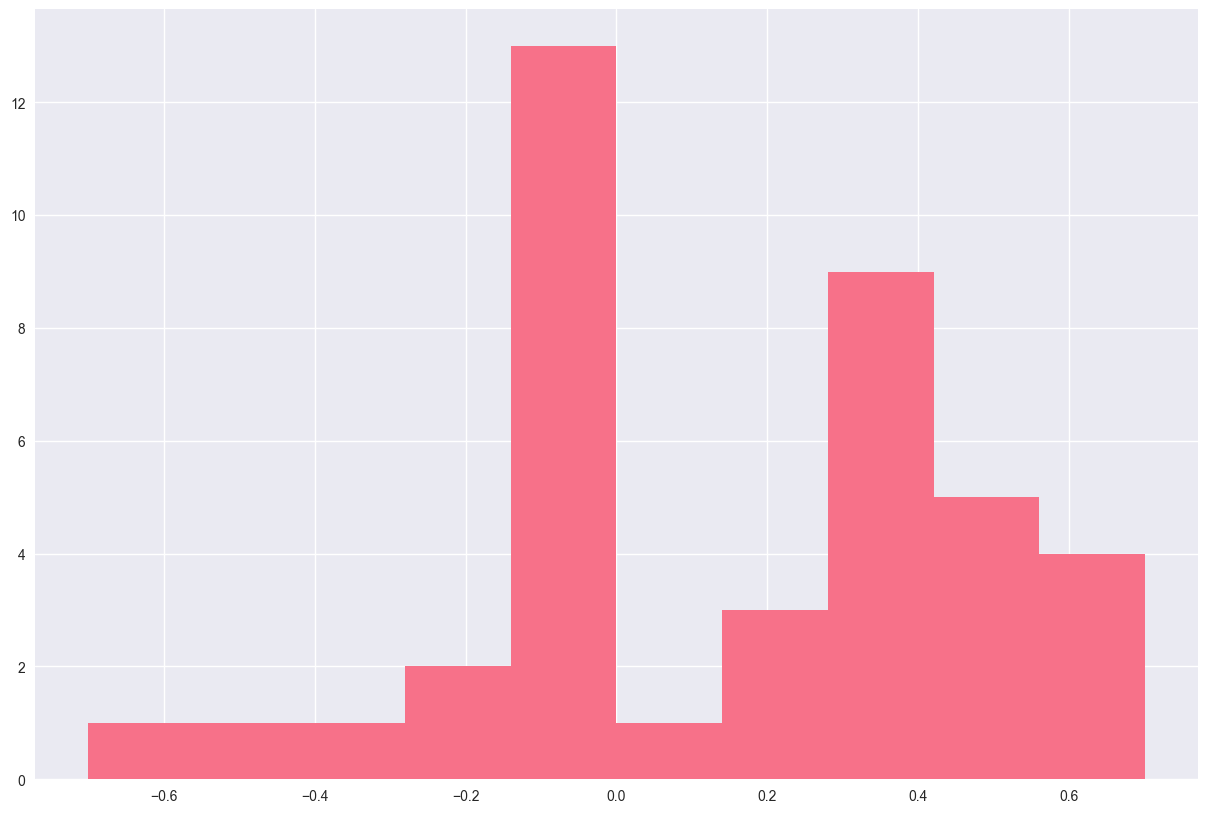

In [43]:
X_train_features['compound_sentiment'].hist()

In [40]:
X_test_tfidf.data, tfidf_vectorizer.get_feature_names_out()

(array([0.60441438, 0.60441438, 0.51900531, 1.        , 1.        ,
        0.79400997, 0.60790473, 0.52806201, 0.52806201, 0.40429139,
        0.52806201, 1.        , 0.70710678, 0.70710678, 0.4248134 ,
        0.46154348, 0.46154348, 0.4248134 , 0.46154348, 0.54407815,
        0.54407815, 0.3964561 , 0.50077988, 0.73577738, 0.67722349]),
 array(['access', 'address', 'autom', 'base', 'career', 'comput', 'condit',
        'connect', 'conserv', 'content', 'cooper', 'cost', 'decis',
        'digit', 'diseas', 'divers', 'econom', 'educ', 'enabl', 'energi',
        'engin', 'ensur', 'environment', 'experi', 'financi', 'genet',
        'global', 'health', 'healthcar', 'improv', 'individu', 'industri',
        'infrastructur', 'initi', 'intern', 'invest', 'learn', 'manag',
        'manufactur', 'market', 'measur', 'medicin', 'minim', 'optim',
        'outcom', 'person', 'plan', 'platform', 'platform provid',
        'practic', 'program', 'promot', 'protect', 'provid', 'recycl',
        'redu

[-0.7003, -0.4404, -0.34, -0.2732, -0.2732, -0.0516, -0.0516, 0.007246376811594203, 0.007936507936507936, 0.007936507936507936, 0.00819672131147541, 0.008547008547008548, 0.008620689655172414, 0.008695652173913044, 0.008695652173913044, 0.008771929824561403, 0.009009009009009009, 0.00909090909090909, 0.00909090909090909, 0.009345794392523364, 0.009433962264150943, 0.009523809523809525, 0.009523809523809525, 0.009523809523809525, 0.009615384615384616, 0.009615384615384616, 0.009708737864077669, 0.009708737864077669, 0.009708737864077669, 0.009708737864077669, 0.00980392156862745, 0.00980392156862745, 0.01, 0.01, 0.01, 0.010101010101010102, 0.010101010101010102, 0.01020408163265306, 0.01020408163265306, 0.01020408163265306, 0.010416666666666666, 0.010416666666666666, 0.010416666666666666, 0.010416666666666666, 0.010526315789473684, 0.010752688172043012, 0.010752688172043012, 0.010752688172043012, 0.010752688172043012, 0.010752688172043012, 0.010752688172043012, 0.010752688172043012, 0.01

(array([637.,  21.,   0.,   0.,   1.,  14.,  32.,  22.,   9.,   2.]),
 array([ -0.7003 ,  13.16973,  27.03976,  40.90979,  54.77982,  68.64985,
         82.51988,  96.38991, 110.25994, 124.12997, 138.     ]),
 <BarContainer object of 10 artists>)

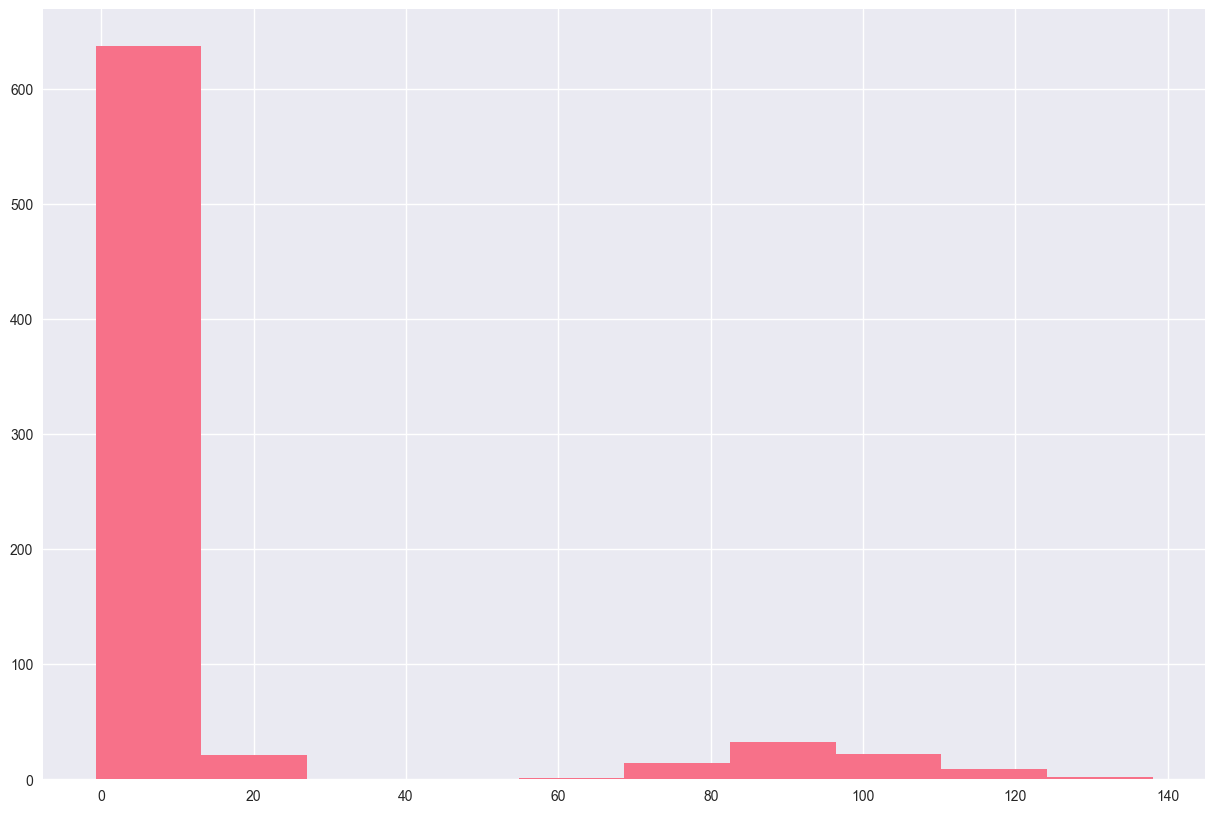

In [34]:
print(X_train_combined.data.tolist())
plt.hist(X_train_combined.data)



In [45]:
# Initialize base classifiers
base_classifiers = {
    # 'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
    # 'Naive Bayes (Complement)': ComplementNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000, C=1.0),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate base classifiers
base_results = {}
print("🔍 Training base classifiers...")

for name, classifier in base_classifiers.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    classifier.fit(X_train_combined, y_train)
    
    # Make predictions
    y_pred = classifier.predict(X_test_combined)
    y_pred_proba = classifier.predict_proba(X_test_combined) if hasattr(classifier, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # Store results
    base_results[name] = {
        'classifier': classifier,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred,
        'predictions_proba': y_pred_proba
    }
    
    print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

# Display base results summary
base_results_df = pd.DataFrame({
    'Classifier': list(base_results.keys()),
    'Accuracy': [base_results[name]['accuracy'] for name in base_results.keys()],
    'Precision': [base_results[name]['precision'] for name in base_results.keys()],
    'Recall': [base_results[name]['recall'] for name in base_results.keys()],
    'F1-Score': [base_results[name]['f1_score'] for name in base_results.keys()]
})

print(f"\n📊 Base Classifiers Results Summary:")
print(base_results_df.round(3))

🔍 Training base classifiers...

Training Logistic Regression...
✅ Logistic Regression - Accuracy: 0.2000, F1: 0.0667

Training Linear SVM...
✅ Linear SVM - Accuracy: 0.2000, F1: 0.0667

Training Random Forest...
✅ Random Forest - Accuracy: 0.6000, F1: 0.5810

Training Gradient Boosting...
✅ Gradient Boosting - Accuracy: 0.8000, F1: 0.7200

Training AdaBoost...
✅ AdaBoost - Accuracy: 0.4000, F1: 0.2889

📊 Base Classifiers Results Summary:
            Classifier  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression       0.2      0.040     0.2     0.067
1           Linear SVM       0.2      0.040     0.2     0.067
2        Random Forest       0.6      0.680     0.6     0.581
3    Gradient Boosting       0.8      0.667     0.8     0.720
4             AdaBoost       0.4      0.257     0.4     0.289


In [46]:
# Create ensemble classifiers
print("🔍 Creating ensemble classifiers...")

# Voting Classifier (Hard Voting)
voting_classifier = VotingClassifier(
    estimators=[(name, classifier) for name, classifier in base_classifiers.items()],
    voting='hard'
)

# Voting Classifier (Soft Voting)
soft_voting_classifier = VotingClassifier(
    estimators=[(name, classifier) for name, classifier in base_classifiers.items() 
               if hasattr(classifier, 'predict_proba')],
    voting='soft'
)

# Bagging Classifier
bagging_classifier = BaggingClassifier(
    base_estimator=RandomForestClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)

# Train ensemble classifiers
ensemble_classifiers = {
    'Hard Voting': voting_classifier,
    'Soft Voting': soft_voting_classifier,
    'Bagging': bagging_classifier
}

ensemble_results = {}
for name, classifier in ensemble_classifiers.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    classifier.fit(X_train_combined, y_train)
    
    # Make predictions
    y_pred = classifier.predict(X_test_combined)
    y_pred_proba = classifier.predict_proba(X_test_combined) if hasattr(classifier, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # Store results
    ensemble_results[name] = {
        'classifier': classifier,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred,
        'predictions_proba': y_pred_proba
    }
    
    print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

# Combine all results
all_results = {**base_results, **ensemble_results}

# Display final results summary
final_results_df = pd.DataFrame({
    'Classifier': list(all_results.keys()),
    'Accuracy': [all_results[name]['accuracy'] for name in all_results.keys()],
    'Precision': [all_results[name]['precision'] for name in all_results.keys()],
    'Recall': [all_results[name]['recall'] for name in all_results.keys()],
    'F1-Score': [all_results[name]['f1_score'] for name in all_results.keys()]
})

print(f"\n📊 Final Results Summary (All Classifiers):")
print(final_results_df.round(4).sort_values('F1-Score', ascending=False))

🔍 Creating ensemble classifiers...


TypeError: __init__() got an unexpected keyword argument 'base_estimator'

## 6. Advanced Model Evaluation and Analysis

Let's perform comprehensive evaluation with detailed metrics, visualizations, and error analysis.

In [ ]:
# Comprehensive model evaluation
def evaluate_model_comprehensive(y_true, y_pred, y_pred_proba, classifier_name, label_encoder):
    """Comprehensive model evaluation with multiple metrics"""
    
    print(f"\n{'='*80}")
    print(f"📋 Comprehensive Evaluation for {classifier_name}")
    print(f"{'='*80}")
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    print(f"\n📊 Overall Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Per-class metrics
    print(f"\n📋 Per-Class Performance:")
    class_names = label_encoder.classes_
    for i, class_name in enumerate(class_names):
        class_precision = precision_score(y_true, y_pred, labels=[i], average='binary', zero_division=0)
        class_recall = recall_score(y_true, y_pred, labels=[i], average='binary', zero_division=0)
        class_f1 = f1_score(y_true, y_pred, labels=[i], average='binary', zero_division=0)
        
        print(f"{class_name:12} - Precision: {class_precision:.4f}, Recall: {class_recall:.4f}, F1: {class_f1:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🔍 Confusion Matrix:")
    print(cm)
    
    # Classification report
    print(f"\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }

# Evaluate all models comprehensively
evaluation_results = {}
for name, result in all_results.items():
    eval_result = evaluate_model_comprehensive(
        y_test, 
        result['predictions'], 
        result['predictions_proba'], 
        name, 
        label_encoder
    )
    evaluation_results[name] = eval_result

In [ ]:
# Advanced visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Advanced Model Performance Analysis', fontsize=16, fontweight='bold')

# 1. Performance comparison
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(all_results))
width = 0.2

for i, metric in enumerate(metrics):
    values = [evaluation_results[name][metric] for name in all_results.keys()]
    axes[0, 0].bar(x + i*width, values, width, label=metric.replace('_', ' ').title())

axes[0, 0].set_xlabel('Classifiers')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(list(all_results.keys()), rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. F1-Score ranking
f1_scores = [evaluation_results[name]['f1_score'] for name in all_results.keys()]
classifier_names = list(all_results.keys())
sorted_indices = np.argsort(f1_scores)[::-1]

axes[0, 1].barh(range(len(sorted_indices)), 
                [f1_scores[i] for i in sorted_indices], 
                color='skyblue')
axes[0, 1].set_yticks(range(len(sorted_indices)))
axes[0, 1].set_yticklabels([classifier_names[i] for i in sorted_indices])
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('F1-Score Ranking')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion matrix heatmap for best model
best_model_name = max(all_results.keys(), key=lambda x: evaluation_results[x]['f1_score'])
best_cm = evaluation_results[best_model_name]['confusion_matrix']

sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, ax=axes[0, 2])
axes[0, 2].set_title(f'Confusion Matrix - {best_model_name}')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

# 4. Precision vs Recall scatter
precisions = [evaluation_results[name]['precision'] for name in all_results.keys()]
recalls = [evaluation_results[name]['recall'] for name in all_results.keys()]

scatter = axes[1, 0].scatter(precisions, recalls, s=100, alpha=0.7, c=range(len(all_results)), cmap='viridis')
for i, name in enumerate(all_results.keys()):
    axes[1, 0].annotate(name, (precisions[i], recalls[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
